# Full-domain surrogate — `full_domain`

Final production model: full **800×800** domain, **12 levels (15–195 m)**, high_weight=0,
non-negativity kept (~1.6 M parameters). Per-layer metrics on the test set, then three
example snapshots (best of each episode) in the paper composite format — per-level
**truth | prediction** with one shared colour scale per level, followed by the
**relative difference** map (% of truth).

In [1]:
import sys; sys.path.insert(0,'../../src')
import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
from pathlib import Path
from dataloader import PALMDatasetV2
from model import UNet3DFiLM
OUT=Path('../../outputs'); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
hf={'london_cm20190720-23':set(range(1,25)),'london_cm20190820-23':set(range(25,49)),'london_cm20190904-07':set(range(49,73))}
ZH=[15,25,35,45,55,75,95,115,135,155,175,195]; NZ=12
CMAP='viridis'; WIDEN=0.0   # full-domain convention: no widening
RUN='full_domain'
ck=torch.load(OUT/RUN/'checkpoints'/'best.pt',map_location='cpu',weights_only=False)
model=UNet3DFiLM(in_ch=18,spatial_ch=2,base_ch=16,dropout=0.0,n_z=NZ,use_attention=True,n_down=4)
model.load_state_dict(ck['model_state_dict']); model.to(device).eval()
st=ck['norm_stats']
ds=PALMDatasetV2(normalise=True,roi=None,hour_filter=hf,global_pm_norm=False,em_bg_norm=True,t_hist=1,z_range=(0,NZ)); ds._stats=st
mean=torch.tensor(st['pm25']['mean'][:NZ]).view(-1,1,1); std=torch.tensor(st['pm25']['std'][:NZ]).view(-1,1,1)
print('full-domain test samples',len(ds))

full-domain test samples 72


In [2]:
# per-layer + pooled performance (z0-11)
def pc(a,b):
    am=a-a.mean();bm=b-b.mean();d=np.sqrt((am**2).sum()*(bm**2).sum())
    return float((am*bm).sum()/d) if d>1e-9 else np.nan
agg={z:{'r':[],'p':[],'s':[]} for z in range(NZ)}
ssr=np.zeros(NZ); cnt=np.zeros(NZ); snap_r=np.full(len(ds),np.nan)
with torch.no_grad():
    for i in range(len(ds)):
        x,y,mk=ds[i]; t=torch.expm1(y*std+mean).numpy(); msk=mk.numpy().astype(bool)
        p=torch.expm1(model(x.unsqueeze(0).to(device)).cpu()[0]*std+mean).numpy()
        rs=[]
        for z in range(NZ):
            s=msk[z]; a=t[z][s].astype(np.float64); b=p[z][s].astype(np.float64)
            if a.size<10 or a.std()<1e-6: continue
            ssr[z]+=((b-a)**2).sum(); cnt[z]+=a.size
            agg[z]['r'].append(np.sqrt(np.mean((b-a)**2))); r=pc(a,b); agg[z]['p'].append(r); agg[z]['s'].append(b.std()/a.std()); rs.append(r)
        snap_r[i]=np.mean(rs) if rs else np.nan
mn=lambda l:np.mean(l) if l else np.nan
print(f'{"height":>8}{"RMSE":>9}{"r":>8}{"sigma":>8}   (full domain test set)')
print('-'*40)
for z in range(NZ):
    a=agg[z]; print(f'{ZH[z]:>6}m {mn(a["r"]):>9.3f}{mn(a["p"]):>8.3f}{mn(a["s"]):>8.2f}')
PP=[x for z in range(NZ) for x in agg[z]['p']]
print(f'\nz0-11 overall: pooled RMSE {np.sqrt(ssr.sum()/cnt.sum()):.3f}   mean r {np.mean(PP):.3f}')
CASES=[(49,'idx49  6 Sep 2019 02:00 (calm night)'),(59,'idx59  6 Sep 2019 12:00 (noon)'),(39,'idx39  21 Aug 2019 16:00 (afternoon, hardest)')]
print('cases:',CASES)

  height     RMSE       r   sigma   (full domain test set)
----------------------------------------
    15m     2.003   0.955    0.98
    25m     1.774   0.947    0.94
    35m     1.371   0.945    0.93
    45m     1.091   0.940    0.93
    55m     0.949   0.930    0.93
    75m     0.665   0.889    0.91
    95m     0.501   0.852    0.90
   115m     0.400   0.829    0.89
   135m     0.339   0.832    0.88
   155m     0.288   0.841    0.87
   175m     0.257   0.844    0.85
   195m     0.237   0.839    0.81

z0-11 overall: pooled RMSE 0.755   mean r 0.887
cases: [(49, 'idx49  6 Sep 2019 02:00 (calm night)'), (59, 'idx59  6 Sep 2019 12:00 (noon)'), (39, 'idx39  21 Aug 2019 16:00 (afternoon, hardest)')]


## Climatology baseline

Non-parametric reference: predict every test hour with the **per-cell temporal mean of the
training set** (one constant field, no model). It shows whether the surrogate beats simply
predicting each cell's historical average. Same pooled RMSE / mean-r definitions as above.

In [3]:
# Training hours = every hour except the held-out test hours (hf) used above.
SIMH={'london_cm20190720-23':96,'london_cm20190820-23':96,'london_cm20190904-07':144}
hf_tr={s:(set(range(1,SIMH[s]+1)) - hf.get(s,set())) for s in SIMH}
ds_tr=PALMDatasetV2(normalise=True,roi=None,hour_filter=hf_tr,global_pm_norm=False,em_bg_norm=True,t_hist=1,z_range=(0,NZ)); ds_tr._stats=st

# Per-cell mean of the physical (expm1) target over the training set.
ssum=scnt=None
for i in range(len(ds_tr)):
    _,y,mk=ds_tr[i]; tp=torch.expm1(y*std+mean).numpy(); m=mk.numpy().astype(bool)
    if ssum is None: ssum=np.zeros_like(tp); scnt=np.zeros_like(tp)
    ssum+=np.where(m,tp,0.0); scnt+=m
clim=ssum/np.maximum(scnt,1)                      # (NZ,H,W) climatology field

# Evaluate the constant climatology field on the test set (same metrics as the model).
ssr_c=np.zeros(NZ); cnt_c=np.zeros(NZ); rc=[]
for i in range(len(ds)):
    _,y,mk=ds[i]; t=torch.expm1(y*std+mean).numpy(); m=mk.numpy().astype(bool)
    for z in range(NZ):
        s=m[z]; a=t[z][s].astype(np.float64); b=clim[z][s].astype(np.float64)
        if a.size<10 or a.std()<1e-6: continue
        ssr_c[z]+=((b-a)**2).sum(); cnt_c[z]+=a.size; rc.append(pc(a,b))
rmse_clim=np.sqrt(ssr_c.sum()/cnt_c.sum()); r_clim=np.mean(rc)
rmse_mod =np.sqrt(ssr.sum()/cnt.sum());     r_mod =np.mean(PP)
print(f'{"":26}{"RMSE":>8}{"r":>8}')
print('-'*42)
print(f'{"Climatology (train mean)":26}{rmse_clim:>8.3f}{r_clim:>8.3f}')
print(f'{"UNet3DFiLM (this work)":26}{rmse_mod:>8.3f}{r_mod:>8.3f}')

                              RMSE       r
------------------------------------------
Climatology (train mean)     2.824   0.620
UNet3DFiLM (this work)       0.755   0.887


In [4]:
# per level: truth | prediction | relative error (%). 2 levels per row -> 6 panels per row.
def plot_case(si):
    x,y,mk=ds[si]; mask=mk.numpy().astype(bool)
    with torch.no_grad(): out=model(x.unsqueeze(0).to(device)).cpu()[0]
    truth=torch.expm1(y*std+mean).numpy(); pred=torch.expm1(out*std+mean).numpy()
    rel=100.0*(pred-truth)/np.where(truth>1e-6,truth,np.nan)
    levels=list(range(NZ)); npr=2; nrows=(len(levels)+npr-1)//npr
    # per level block: truth, pred, shared-cbar, spacer, err, err-cbar ; big gap between blocks
    wr=[]; blocks=[]; ci=0
    for L in range(npr):
        blocks.append((ci,ci+1,ci+2,ci+4,ci+5)); wr+=[1,1,0.06,0.16,1,0.06]; ci+=6
        if L<npr-1: wr+=[0.38]; ci+=1
    fig=plt.figure(figsize=(14,2.35*nrows))
    gs=GridSpec(nrows,len(wr),width_ratios=wr,wspace=0.05,hspace=0.28)
    for i,z in enumerate(levels):
        r=i//npr; L=i%npr; ct,cp,cc1,ce,cc2=blocks[L]
        axt=fig.add_subplot(gs[r,ct]); axp=fig.add_subplot(gs[r,cp]); axc1=fig.add_subplot(gs[r,cc1])
        axe=fig.add_subplot(gs[r,ce]); axc2=fig.add_subplot(gs[r,cc2])
        ti=np.where(mask[z],truth[z],np.nan); pi=np.where(mask[z],pred[z],np.nan); ei=np.where(mask[z],rel[z],np.nan)
        if mask[z].sum()>=10:
            a=truth[z][mask[z]]; b=pred[z][mask[z]]
            vmin=min(np.percentile(a,1),np.percentile(b,1)); vmax=max(np.percentile(a,99),np.percentile(b,99))
            if z>=5 and WIDEN>0: s=vmax-vmin; vmin-=WIDEN*s; vmax+=WIDEN*s
            el=np.nanpercentile(np.abs(ei),98)+1e-9
        else: vmin,vmax,el=0.0,1.0,1.0
        imt=axt.imshow(ti,cmap=CMAP,vmin=vmin,vmax=vmax,origin='lower')
        axp.imshow(pi,cmap=CMAP,vmin=vmin,vmax=vmax,origin='lower')
        ime=axe.imshow(ei,cmap='RdBu_r',vmin=-el,vmax=el,origin='lower')
        for ax in (axt,axp,axe): ax.set_xticks([]); ax.set_yticks([])
        axt.set_title(f'{ZH[z]}m truth',fontsize=9); axp.set_title(f'{ZH[z]}m pred',fontsize=9); axe.set_title(f'{ZH[z]}m diff',fontsize=9)
        plt.colorbar(imt,cax=axc1)
        cb=plt.colorbar(ime,cax=axc2); cb.ax.yaxis.set_major_formatter(FuncFormatter(lambda v,p: f'{v:+.0f}%'))
        axc1.tick_params(labelsize=7.5); axc2.tick_params(labelsize=7.5)
    import os; os.makedirs('figs', exist_ok=True)
    fig.savefig(f'figs/{RUN}_idx{si}.png', dpi=300, bbox_inches='tight')
    plt.show()
print('ready')

ready


### idx49 — 6 Sep 2019 02:00 (calm night)

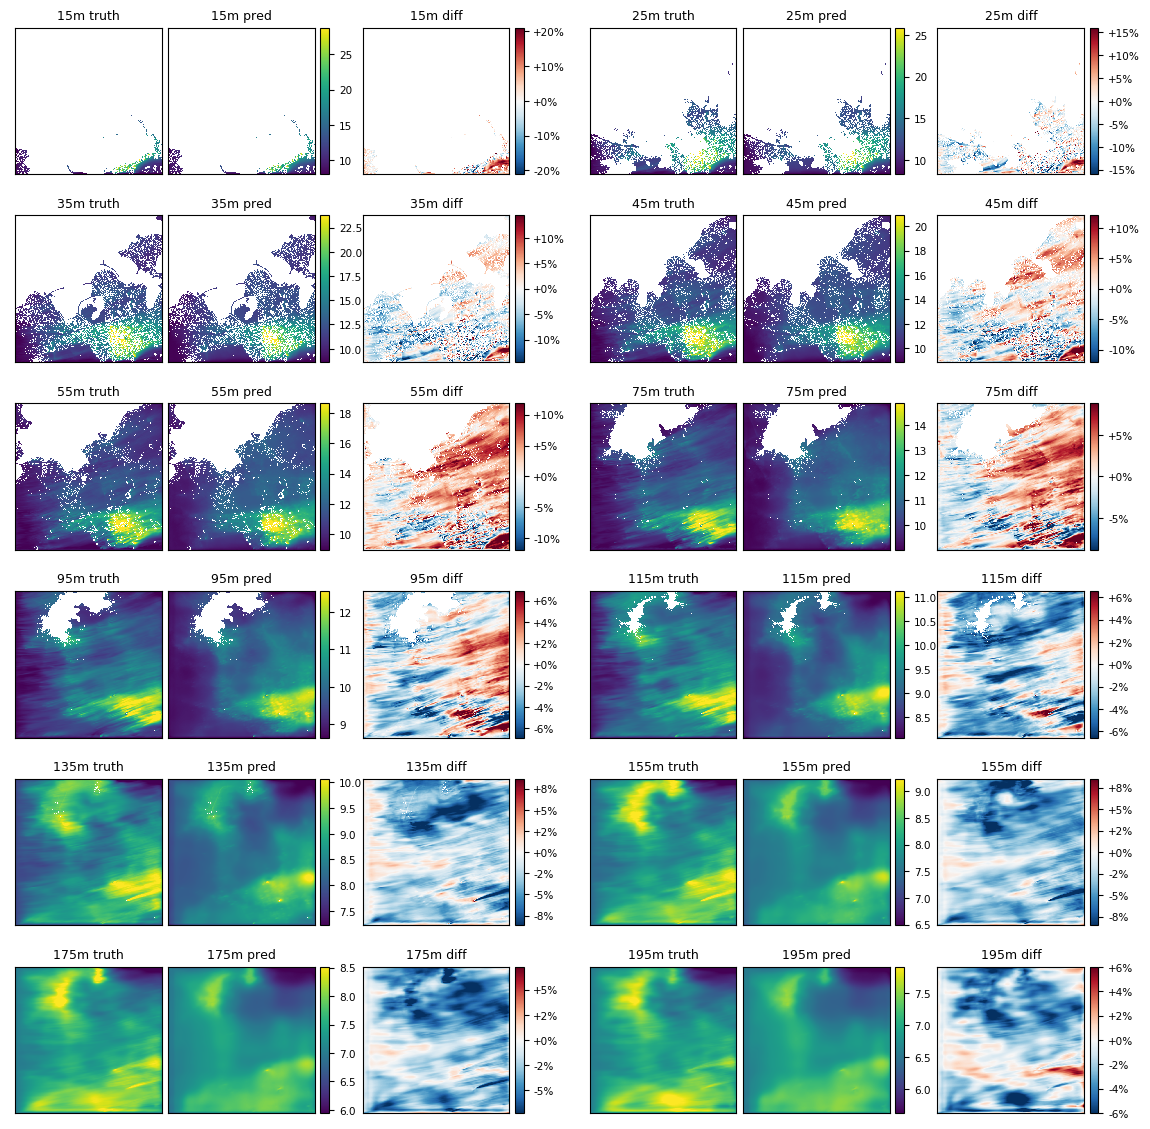

In [5]:
plot_case(49)

### idx59 — 6 Sep 2019 12:00 (noon)

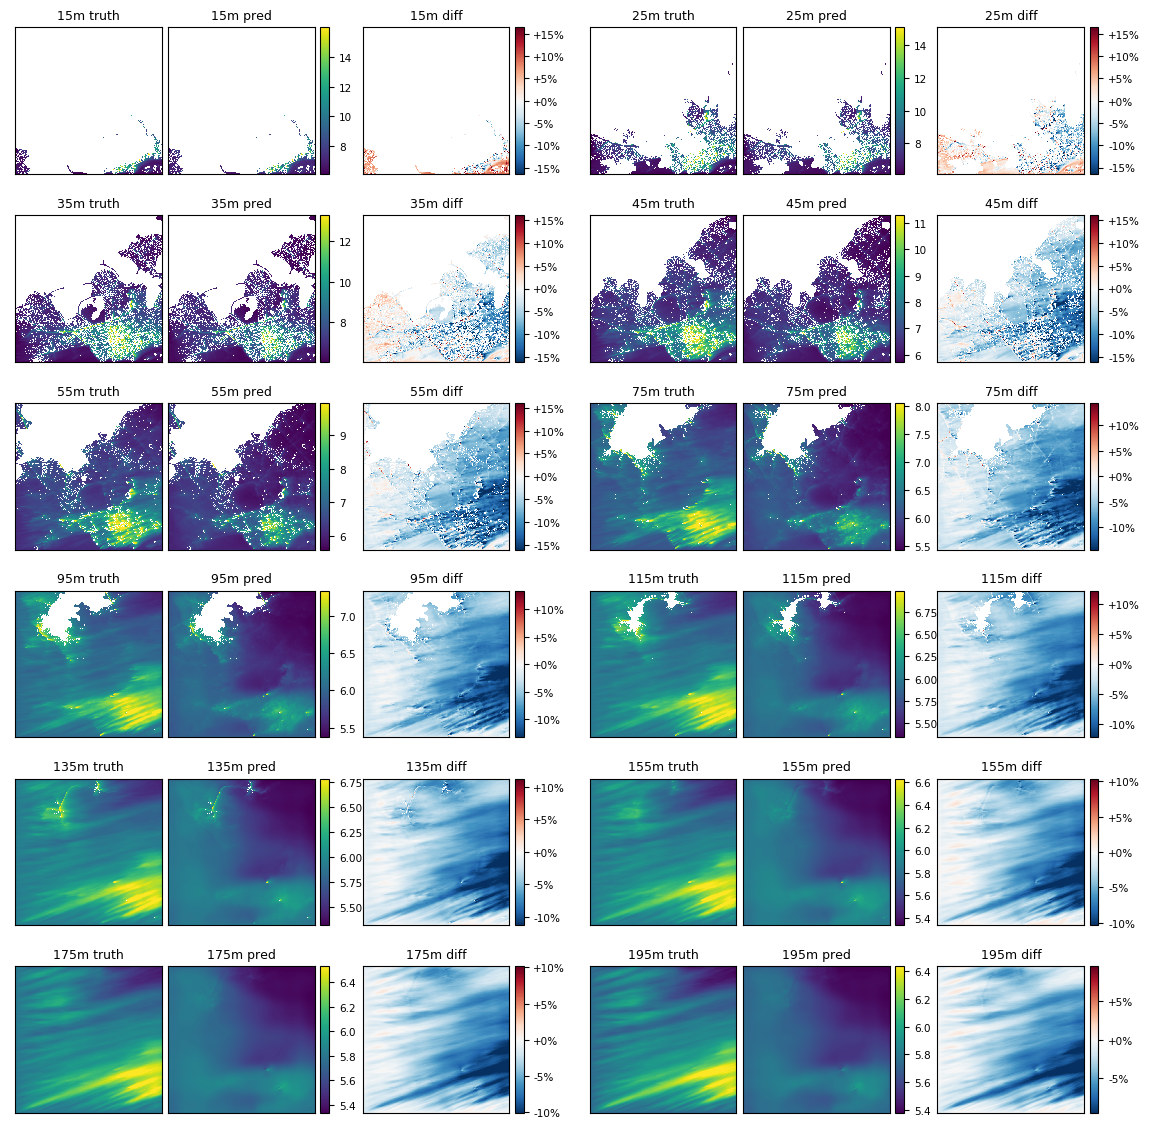

In [6]:
plot_case(59)

### idx39 — 21 Aug 2019 16:00 (afternoon, hardest)

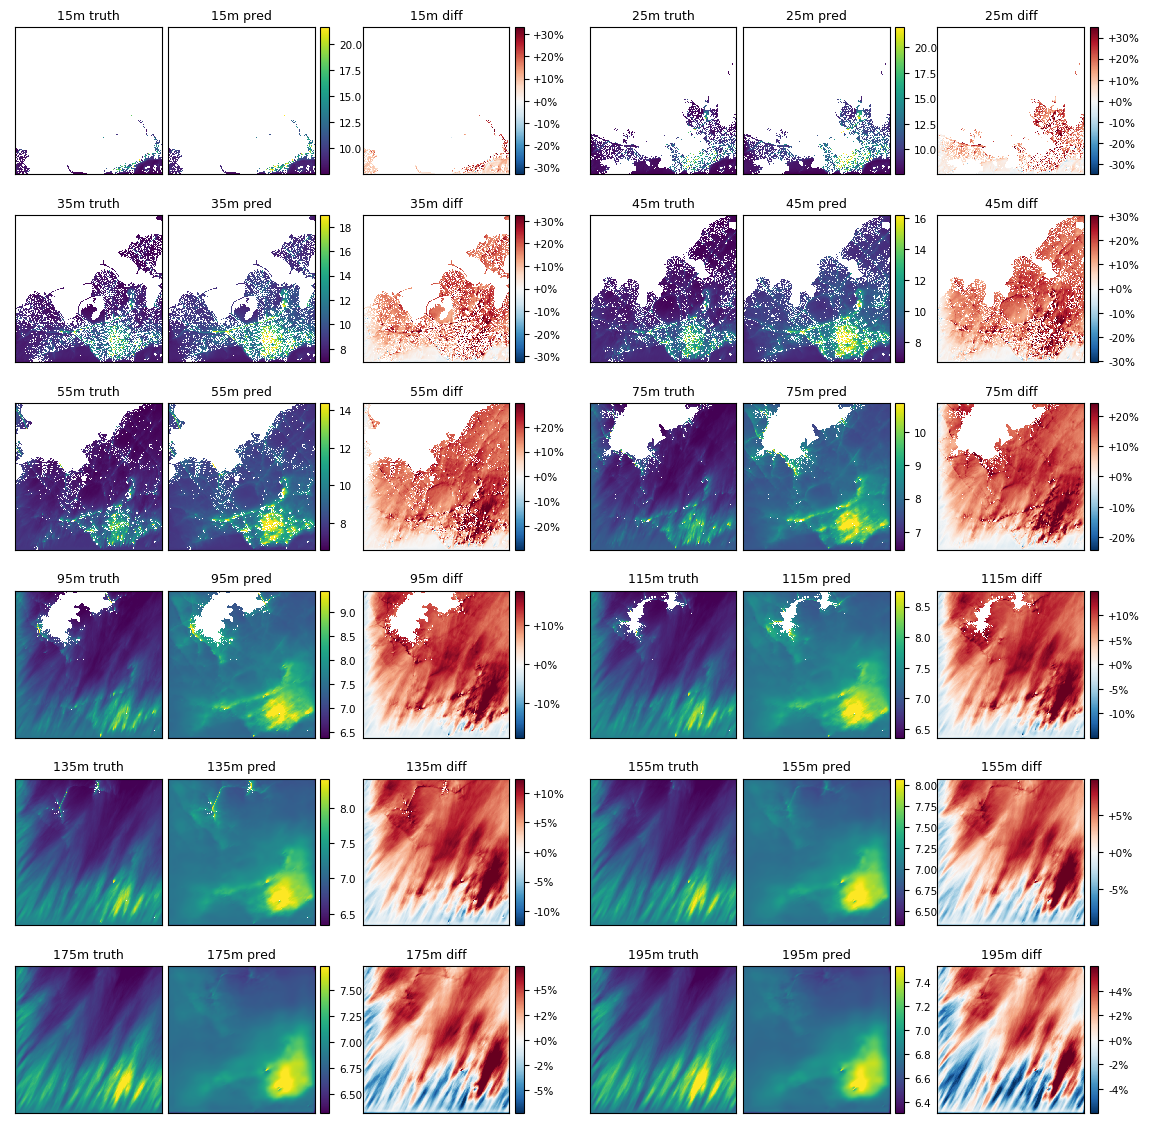

In [7]:
plot_case(39)